<a href="https://colab.research.google.com/github/bhaviii123/Air_Passenger_Forecasting_ML_vs_DL.ipynb/blob/main/Air_passengeser_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 1: Data Preprocessing & Windowing

In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Load dataset (Air Passengers)
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
df = pd.read_csv(url, usecols=[1])
data = df.values.astype('float32')

# 1. Scaling
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# 2. Creating Sliding Windows
def create_sequences(data, window_size=12):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, window_size=12)

# 3. Reshaping for LSTM [samples, time_steps, features]
X = X.reshape((X.shape[0], X.shape[1], 1))

Step 2: Building the 7-Layer Deep LSTM

In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    # Layer 1 (Input)
    LSTM(64, return_sequences=True, input_shape=(12, 1)),
    Dropout(0.2),

    # Layers 2 - 5 (Stacked Hidden Layers)
    LSTM(64, return_sequences=True),
    LSTM(32, return_sequences=True),
    LSTM(32, return_sequences=True),
    LSTM(16, return_sequences=True),

    # Layer 6 (Transition to Output)
    LSTM(16, return_sequences=False),

    # Layer 7 (Output Prediction)
    Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Step 3: Training the Model

In [7]:
# Take the last 12 months of the real dataset
current_batch = scaled_data[-12:].reshape(1, 12, 1)
future_preds = []

for i in range(4): # 4 months \u2248 100+ days
    # Get the prediction for the next month
    current_pred = model.predict(current_batch)[0]
    future_preds.append(current_pred)

    # Update current_batch: Remove first month, add the new prediction
    current_batch = np.append(current_batch[:, 1:, :], [[current_pred]], axis=1)

# Transform back to original passenger counts
future_preds_actual = scaler.inverse_transform(future_preds)

print(f"Predicted future passenger counts (next 4 months):\n{future_preds_actual}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Predicted future passenger counts (next 4 months):
[[332.71264632]
 [307.4734617 ]
 [308.30662915]
 [316.50811834]]


Step 4: Predicting the Next 100 Days (Recursive)

In [10]:
# Take the last 12 months of the real dataset
current_batch = scaled_data[-12:].reshape(1, 12, 1)
future_preds = []

for i in range(4): # 4 months ≈ 100+ days
    # Get the prediction for the next month
    current_pred = model.predict(current_batch)[0]
    future_preds.append(current_pred)

    # Update current_batch: Remove first month, add the new prediction
    current_batch = np.append(current_batch[:, 1:, :], [[current_pred]], axis=1)

# Transform back to original passenger counts
future_preds_actual = scaler.inverse_transform(future_preds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


In [11]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Note: y_test is already scaled, but test_predict was inverse_transformed for plotting.
# To calculate metrics correctly, we need to ensure both are in the same scale.
# Since y_test represents the actual scaled values, we should compare it with scaled predictions
# or inverse_transform y_test as well.

# Let's use the inverse_transformed test_predict and inverse_transform y_test for meaningful metrics.
# y_test is currently scaled, and test_predict was scaled before inverse_transform for plotting.
# It's better to compare inverse_transformed values to understand accuracy in original units.

y_test_actual = scaler.inverse_transform(y_test)

mse = mean_squared_error(y_test_actual, test_predict)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_actual, test_predict)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")

Mean Squared Error (MSE): 8073.83
Root Mean Squared Error (RMSE): 89.85
Mean Absolute Error (MAE): 77.09


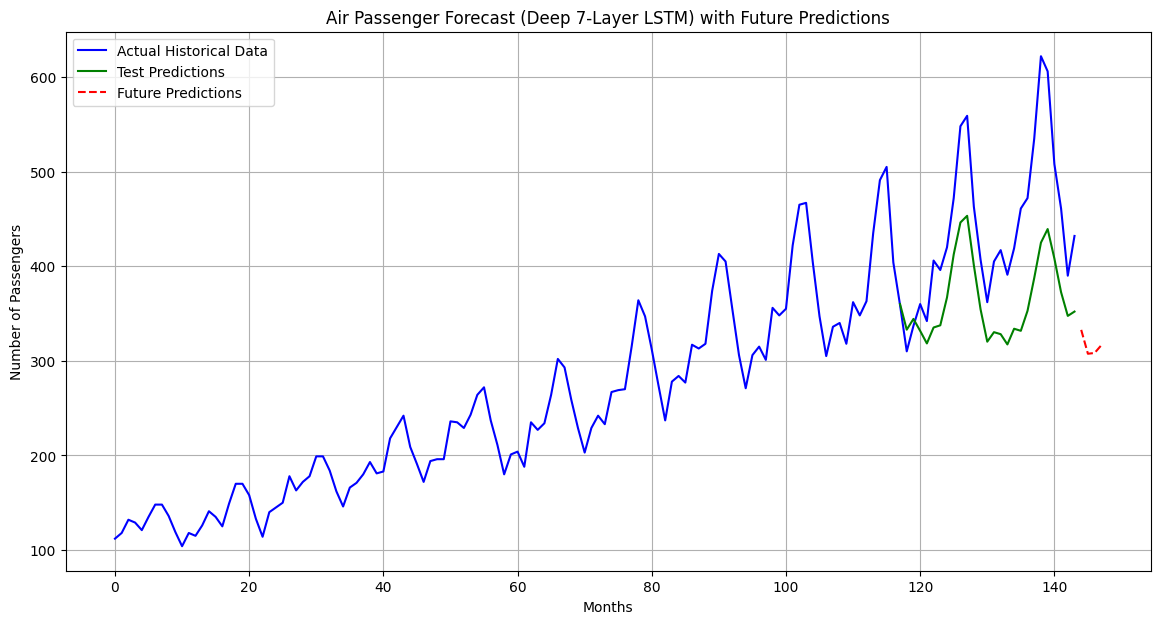

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Create an index for the future predictions
# Initialize future_plot_idx to be large enough to hold actual_data + future_preds
future_plot_idx = np.full((len(actual_data) + len(future_preds_actual), 1), np.nan)

# Place the future predictions after the historical data
# Predictions start at index len(actual_data)
future_plot_idx[len(actual_data):len(actual_data) + len(future_preds_actual), :] = future_preds_actual

plt.figure(figsize=(14, 7))
plt.plot(actual_data, label='Actual Historical Data', color='blue')
plt.plot(test_plot_idx, label='Test Predictions', color='green')
plt.plot(future_plot_idx, label='Future Predictions', color='red', linestyle='--')

plt.title('Air Passenger Forecast (Deep 7-Layer LSTM) with Future Predictions')
plt.xlabel('Months')
plt.ylabel('Number of Passengers')
plt.legend()
plt.grid(True)
plt.show()

Step 5: Visualizing Results

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


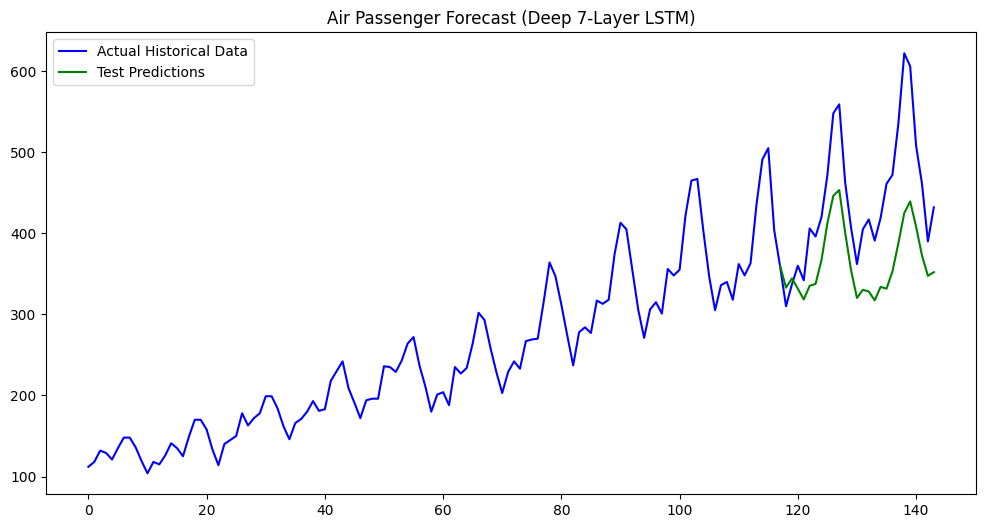

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming window_size is globally available or defined earlier, for clarity adding it here.
# It was defined in cell 3WIMBo41MqhY
window_size = 12

# Prepare data for plotting
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Invert all scales for plotting
train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)
actual_data = scaler.inverse_transform(scaled_data)

plt.figure(figsize=(12,6))
plt.plot(actual_data, label='Actual Historical Data', color='blue')

# Offset test predictions for correct alignment
test_plot_idx = np.empty_like(actual_data)
test_plot_idx[:, :] = np.nan

# Corrected indexing:
# The test predictions start after the window_size offset and the training data.
# The start index is window_size + len(train_predict)
# The end index is window_size + len(train_predict) + len(test_predict), which equals len(actual_data)
test_plot_idx[window_size + len(train_predict) : len(actual_data), :] = test_predict

plt.plot(test_plot_idx, label='Test Predictions', color='green')
plt.title('Air Passenger Forecast (Deep 7-Layer LSTM)')
plt.legend()
plt.show()

1. Simple RNN (The Baseline)

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

model_rnn = Sequential([
    SimpleRNN(50, activation='relu', input_shape=(12, 1)),
    Dense(1)
])
model_rnn.compile(optimizer='adam', loss='mse')
# model_rnn.fit(X_train, y_train, epochs=100, verbose=0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2. Standard LSTM & GRU

In [13]:
from tensorflow.keras.layers import LSTM, GRU

# --- LSTM Model ---
model_lstm = Sequential([
    LSTM(50, activation='relu', input_shape=(12, 1)),
    Dense(1)
])

# --- GRU Model ---
model_gru = Sequential([
    GRU(50, activation='relu', input_shape=(12, 1)),
    Dense(1)
])

Text(83.34722222222221, 0.5, 'Number of Passengers')

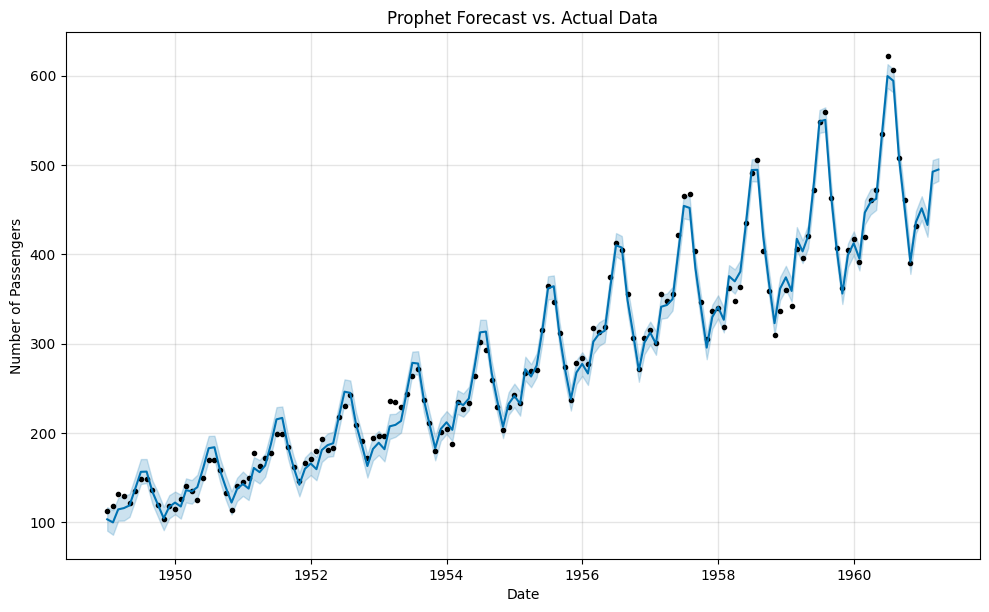

In [25]:
fig1 = model_prophet.plot(forecast)
plt.title('Prophet Forecast vs. Actual Data')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')

3. Deep Stacked LSTM (6 to 7 Layers)

In [14]:
from tensorflow.keras.layers import Dropout, BatchNormalization

model_deep = Sequential()
# Layer 1
model_deep.add(LSTM(64, return_sequences=True, input_shape=(12, 1)))
model_deep.add(BatchNormalization())
# Layers 2, 3, 4, 5 (The Stack)
for _ in range(4):
    model_deep.add(LSTM(64, return_sequences=True))
    model_deep.add(Dropout(0.2))
# Layer 6
model_deep.add(LSTM(32, return_sequences=False))
# Layer 7
model_deep.add(Dense(1))

model_deep.compile(optimizer='adam', loss='mse')

4. CNN-LSTM Hybrid

In [15]:
from tensorflow.keras.layers import Conv1D, MaxPooling1D

model_cnn_lstm = Sequential([
    Conv1D(filters=64, kernel_size=2, activation='relu', input_shape=(12, 1)),
    MaxPooling1D(pool_size=2),
    LSTM(50, activation='relu'),
    Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5. CNN-GRU Hybrid

In [16]:
model_cnn_gru = Sequential([
    Conv1D(filters=64, kernel_size=2, activation='relu', input_shape=(12, 1)),
    MaxPooling1D(pool_size=2),
    GRU(50, activation='relu'),
    Dense(1)
])

6. Sequence-to-Sequence (Encoder-Decoder)

In [17]:
from tensorflow.keras.layers import RepeatVector, TimeDistributed

model_seq2seq = Sequential([
    # Encoder
    LSTM(100, activation='relu', input_shape=(12, 1)),
    # Repeat the state for the number of steps you want to predict (e.g., 4 months)
    RepeatVector(4),
    # Decoder
    LSTM(100, activation='relu', return_sequences=True),
    TimeDistributed(Dense(1))
])

7. Prophet Model (Statistical)

In [20]:
# You must install it first: pip install prophet
from prophet import Prophet
import pandas as pd # Ensure pandas is imported

# Prepare data for Prophet
# Prophet expects columns named 'ds' (datestamp) and 'y' (value)
prophet_df = df.copy()

# Create a 'ds' column. Assuming monthly data starting from 1949-01-01
# The original df has 144 rows, representing 144 months.
prophet_df['ds'] = pd.date_range(start='1949-01-01', periods=len(prophet_df), freq='MS')

# Rename the 'Passengers' column to 'y'
prophet_df = prophet_df.rename(columns={'Passengers': 'y'})

model_prophet = Prophet(seasonality_mode='multiplicative')
model_prophet.fit(prophet_df)

# Create 4 future months (approx 100 days)
future = model_prophet.make_future_dataframe(periods=4, freq='MS')
forecast = model_prophet.predict(future)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [22]:
# You must install it first: pip install prophet
from prophet import Prophet
import pandas as pd # Ensure pandas is imported

# Prepare data for Prophet
# Prophet expects columns named 'ds' (datestamp) and 'y' (value)
prophet_df = df.copy()

# Create a 'ds' column. Assuming monthly data starting from 1949-01-01
# The original df has 144 rows, representing 144 months.
prophet_df['ds'] = pd.date_range(start='1949-01-01', periods=len(prophet_df), freq='MS')

# Rename the 'Passengers' column to 'y'
prophet_df = prophet_df.rename(columns={'Passengers': 'y'})

model_prophet = Prophet(seasonality_mode='multiplicative')
model_prophet.fit(prophet_df)

# Create 4 future months (approx 100 days)
future = model_prophet.make_future_dataframe(periods=4, freq='MS')
forecast = model_prophet.predict(future)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


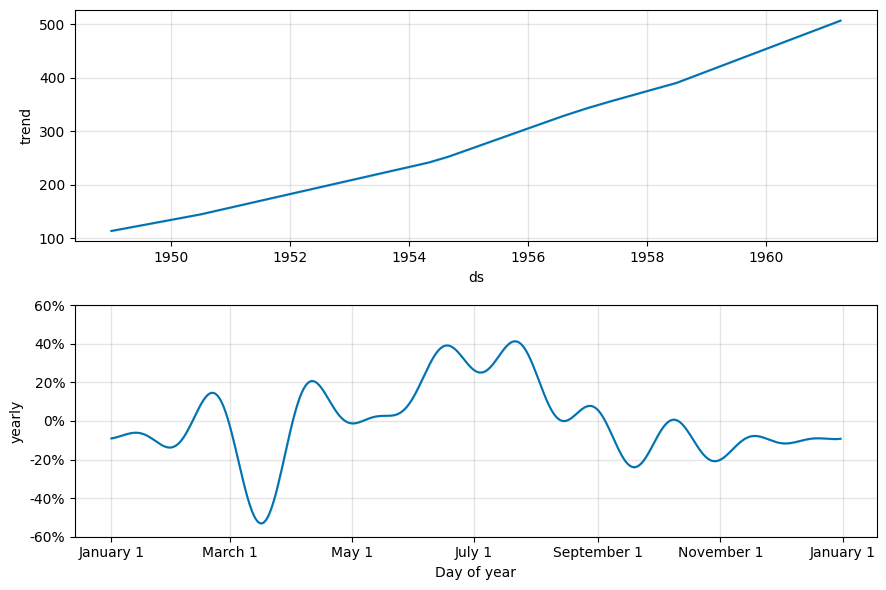

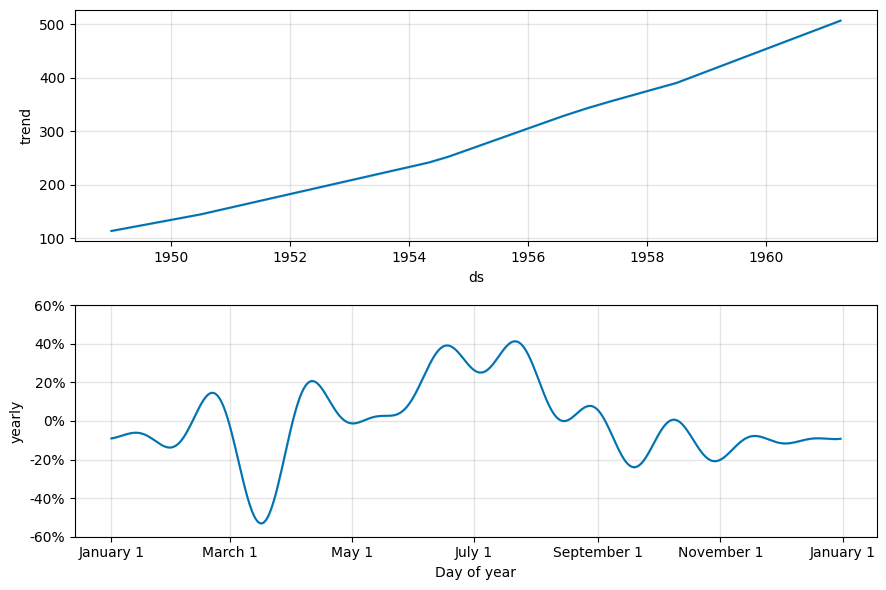

In [21]:
model_prophet.plot_components(forecast)

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, GRU, SimpleRNN, Conv1D, MaxPooling1D, Flatten, Dropout, BatchNormalization

# --- STEP 1: DATA PREP ---
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
df = pd.read_csv(url, usecols=[1])
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df.values.astype('float32'))

def create_window(data, window=12):
    X, y = [], []
    for i in range(len(data)-window):
        X.append(data[i:i+window, 0])
        y.append(data[i+window, 0])
    return np.array(X), np.array(y)

X, y = create_window(scaled_data)
X = X.reshape((X.shape[0], X.shape[1], 1))
split = int(len(X) * 0.8)
X_train, X_test, y_train, y_test = X[:split], X[split:], y[:split], y[split:]

# --- STEP 2: MODEL DEFINITIONS ---
def get_models():
    models = {}

    # 1. Simple RNN
    models['RNN'] = Sequential([SimpleRNN(50, input_shape=(12, 1)), Dense(1)])

    # 2. LSTM
    models['LSTM'] = Sequential([LSTM(50, input_shape=(12, 1)), Dense(1)])

    # 3. GRU
    models['GRU'] = Sequential([GRU(50, input_shape=(12, 1)), Dense(1)])

    # 4. Deep 7-Layer LSTM
    deep_lstm = Sequential()
    deep_lstm.add(LSTM(64, return_sequences=True, input_shape=(12, 1)))
    for _ in range(4): deep_lstm.add(LSTM(32, return_sequences=True))
    deep_lstm.add(LSTM(16, return_sequences=False))
    deep_lstm.add(Dense(1))
    models['Deep_7L_LSTM'] = deep_lstm

    # 5. CNN-LSTM
    models['CNN-LSTM'] = Sequential([
        Conv1D(64, 2, activation='relu', input_shape=(12, 1)),
        MaxPooling1D(2),
        LSTM(50),
        Dense(1)
    ])

    # 6. CNN-GRU
    models['CNN-GRU'] = Sequential([
        Conv1D(64, 2, activation='relu', input_shape=(12, 1)),
        MaxPooling1D(2),
        GRU(50),
        Dense(1)
    ])

    return models

# --- STEP 3: TRAIN & EVALUATE ---
results = []
all_models = get_models()

for name, model in all_models.items():
    model.compile(optimizer='adam', loss='mse')
    model.fit(X_train, y_train, epochs=50, batch_size=8, verbose=0)

    # Predict & Invert Scaling
    preds = model.predict(X_test)
    preds_rescaled = scaler.inverse_transform(preds)
    y_test_rescaled = scaler.inverse_transform(y_test.reshape(-1, 1))

    # Calculate Error
    rmse = np.sqrt(mean_squared_error(y_test_rescaled, preds_rescaled))
    results.append({'Model': name, 'RMSE': rmse})

# --- STEP 4: PROPHET (Separate because it's not Keras) ---
from prophet import Prophet
prophet_df = pd.read_csv(url)
# Create a 'ds' column. Assuming monthly data starting from 1949-01-01
# The original df has 144 rows, representing 144 months.
prophet_df['ds'] = pd.date_range(start='1949-01-01', periods=len(prophet_df), freq='MS')
# Rename the 'Passengers' column to 'y'
prophet_df = prophet_df.rename(columns={'Passengers': 'y'})

p_model = Prophet(seasonality_mode='multiplicative').fit(prophet_df)
p_forecast = p_model.predict(prophet_df.iloc[split+12:])
p_rmse = np.sqrt(mean_squared_error(prophet_df['y'].iloc[split+12:], p_forecast['yhat']))
results.append({'Model': 'Prophet', 'RMSE': p_rmse})

# --- FINAL RESULTS ---
comparison_df = pd.DataFrame(results).sort_values(by='RMSE')
print(comparison_df)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 854ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


          Model       RMSE
6       Prophet  11.266538
5       CNN-GRU  30.436379
0           RNN  34.253933
1          LSTM  36.698906
4      CNN-LSTM  54.388551
2           GRU  58.620679
3  Deep_7L_LSTM  60.138577
